In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from typing import TypedDict
from dotenv import load_dotenv


In [2]:
load_dotenv()

True

In [3]:
model = ChatOpenAI()

In [4]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str
    

In [ ]:
def create_outline(state: BlogState) -> BlogState:

    title = state['title']

    prompt = f'Generate a detailed outline for a blog on topi - {title}'

    res = model.invoke(prompt).content

    state['outline'] = res

    return state


def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the {title} using the following outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state


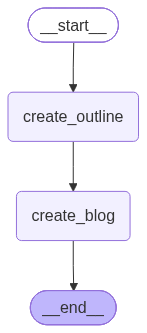

In [6]:
graph = StateGraph(BlogState)

#nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

#edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

blog = graph.compile()
blog

In [7]:
res = blog.invoke({'title': "El-Nino", 'outline': "", 'content': ""})
res

InvalidUpdateError: Expected dict, got <class '__main__.BlogState'>
For troubleshooting, visit: https://docs.langchain.com/oss/python/langgraph/errors/INVALID_GRAPH_NODE_RETURN_VALUE